In [3]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles in this directory:")
print(os.listdir())

Current working directory:
/workspaces/ECON-522-Forecasting-Project/Climate Data

Files in this directory:
['~$Downscaled_GCAM 6.0 NGFS_data.xlsx', 'BUSLOANS.csv', 'CORBLACBS.csv', 'GDPC1.csv', 'Downscaled_GCAM 6.0 NGFS_data.xlsx', 'UNEMPLOYMENT.csv', 'CPI.csv', 'Downscaled_REMIND-MAgPIE 3.3-4.8_data.xlsx', 'Downscaled_MESSAGEix-GLOBIOM 2.0-M-R12-NGFS_data.xlsx', 'Climate Analysis.ipynb', 'IAM_data.xlsx', 'climate_analysis_riddhi.ipynb', 'NiGEM_data.xlsx']


In [4]:
import pandas as pd

bus = pd.read_csv("BUSLOANS.csv")

print("Shape:", bus.shape)
print("\nColumns:")
print(bus.columns)

print("\nFirst 5 rows:")
print(bus.head())

Shape: (949, 2)

Columns:
Index(['observation_date', 'BUSLOANS'], dtype='str')

First 5 rows:
  observation_date  BUSLOANS
0       1947-01-01   11.2894
1       1947-02-01   11.5179
2       1947-03-01   11.7667
3       1947-04-01   12.0269
4       1947-05-01   12.2788


In [5]:
bus["observation_date"] = pd.to_datetime(bus["observation_date"])
bus = bus.rename(columns={"observation_date": "DATE",
                          "BUSLOANS": "busloans"})

bus = bus.sort_values("DATE").reset_index(drop=True)

print(bus.dtypes)
print("\nDate range:")
print(bus["DATE"].min(), "to", bus["DATE"].max())

DATE        datetime64[us]
busloans           float64
dtype: object

Date range:
1947-01-01 00:00:00 to 2026-01-01 00:00:00


In [6]:
date_diffs = bus["DATE"].diff().dropna()

print("Most common date differences:")
print(date_diffs.value_counts().head())

Most common date differences:
DATE
31 days    553
30 days    316
28 days     59
29 days     20
Name: count, dtype: int64


In [7]:
co = pd.read_csv("CORBLACBS.csv")

print("Shape:", co.shape)
print("\nColumns:")
print(co.columns)

print("\nFirst 5 rows:")
print(co.head())

Shape: (163, 2)

Columns:
Index(['observation_date', 'CORBLACBS'], dtype='str')

First 5 rows:
  observation_date  CORBLACBS
0       1985-01-01       1.28
1       1985-04-01       1.20
2       1985-07-01       1.42
3       1985-10-01       1.45
4       1986-01-01       1.46


In [8]:
co["observation_date"] = pd.to_datetime(co["observation_date"])

co = co.rename(columns={
    "observation_date": "DATE",
    "CORBLACBS": "chargeoff_rate"
})

co = co.sort_values("DATE").reset_index(drop=True)

print(co.dtypes)
print("\nDate range:")
print(co["DATE"].min(), "to", co["DATE"].max())

DATE              datetime64[us]
chargeoff_rate           float64
dtype: object

Date range:
1985-01-01 00:00:00 to 2025-07-01 00:00:00


In [9]:
# Find overlap window
start_date = max(bus["DATE"].min(), co["DATE"].min())
end_date = min(bus["DATE"].max(), co["DATE"].max())

print("Overlap period:")
print(start_date, "to", end_date)

Overlap period:
1985-01-01 00:00:00 to 2025-07-01 00:00:00


In [10]:
# Set DATE as index temporarily
bus_q = bus.set_index("DATE")

# Take end-of-quarter value
bus_q = bus_q["busloans"].resample("QE").last()

# Convert back to DataFrame
bus_q = bus_q.to_frame().reset_index()

print("Quarterly BUSLOANS shape:", bus_q.shape)
print("\nFirst 5 rows:")
print(bus_q.head())
print("\nDate range:")
print(bus_q["DATE"].min(), "to", bus_q["DATE"].max())

Quarterly BUSLOANS shape: (317, 2)

First 5 rows:
        DATE  busloans
0 1947-03-31   11.7667
1 1947-06-30   12.4832
2 1947-09-30   13.3523
3 1947-12-31   14.2053
4 1948-03-31   14.7454

Date range:
1947-03-31 00:00:00 to 2026-03-31 00:00:00


In [11]:
# Restrict to overlap window
bus_q_overlap = bus_q[
    (bus_q["DATE"] >= "1985-01-01") &
    (bus_q["DATE"] <= "2025-07-01")
].reset_index(drop=True)

print("Restricted BUSLOANS shape:", bus_q_overlap.shape)
print("\nFirst 5 rows:")
print(bus_q_overlap.head())
print("\nLast 5 rows:")
print(bus_q_overlap.tail())

Restricted BUSLOANS shape: (162, 2)

First 5 rows:
        DATE  busloans
0 1985-03-31  480.0977
1 1985-06-30  482.3543
2 1985-09-30  494.2390
3 1985-12-31  498.9813
4 1986-03-31  505.2190

Last 5 rows:
          DATE   busloans
157 2024-06-30  2765.4940
158 2024-09-30  2777.8983
159 2024-12-31  2765.6419
160 2025-03-31  2675.2916
161 2025-06-30  2685.3006


In [12]:
# We convert charge-off dates from quarter-start to quarter-end timestamps to ensure precise temporal alignment with the resampled quarterly BUSLOANS series before merging.
co_q = co.copy()

co_q["DATE"] = co_q["DATE"].dt.to_period("Q").dt.to_timestamp("Q")

print(co_q.head())
print("\nDate range:")
print(co_q["DATE"].min(), "to", co_q["DATE"].max())
print("\nNumber of observations:", co_q.shape[0])

        DATE  chargeoff_rate
0 1985-03-31            1.28
1 1985-06-30            1.20
2 1985-09-30            1.42
3 1985-12-31            1.45
4 1986-03-31            1.46

Date range:
1985-03-31 00:00:00 to 2025-09-30 00:00:00

Number of observations: 163


In [13]:
# Merge quarterly BUSLOANS and charge-offs
df = bus_q_overlap.merge(co_q, on="DATE", how="inner")

print("Merged shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())

Merged shape: (162, 3)

First 5 rows:
        DATE  busloans  chargeoff_rate
0 1985-03-31  480.0977            1.28
1 1985-06-30  482.3543            1.20
2 1985-09-30  494.2390            1.42
3 1985-12-31  498.9813            1.45
4 1986-03-31  505.2190            1.46

Last 5 rows:
          DATE   busloans  chargeoff_rate
157 2024-06-30  2765.4940            0.48
158 2024-09-30  2777.8983            0.55
159 2024-12-31  2765.6419            0.50
160 2025-03-31  2675.2916            0.56
161 2025-06-30  2685.3006            0.58


In [14]:
import numpy as np

df = df.sort_values("DATE").reset_index(drop=True)

# Quarterly log growth (approx % change)
df["loan_growth"] = np.log(df["busloans"]).diff() * 100

print(df.head(6))

        DATE  busloans  chargeoff_rate  loan_growth
0 1985-03-31  480.0977            1.28          NaN
1 1985-06-30  482.3543            1.20     0.468928
2 1985-09-30  494.2390            1.42     2.434030
3 1985-12-31  498.9813            1.45     0.954941
4 1986-03-31  505.2190            1.46     1.242338
5 1986-06-30  511.2815            1.47     1.192832


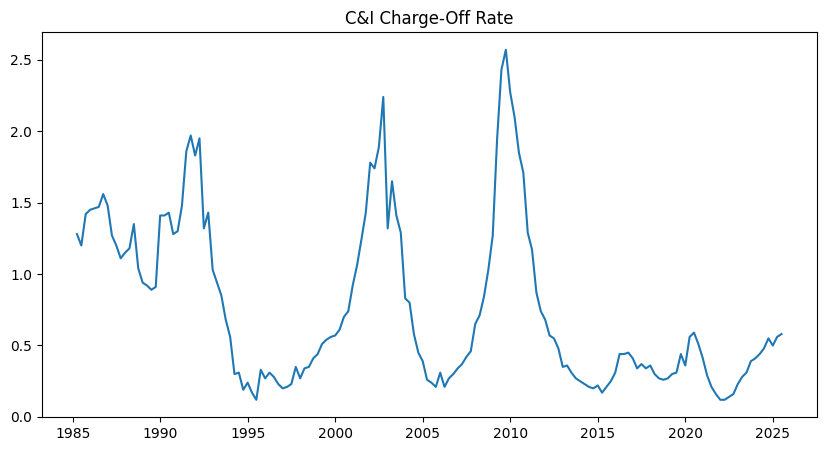

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df["DATE"], df["chargeoff_rate"])
plt.title("C&I Charge-Off Rate")
plt.show()

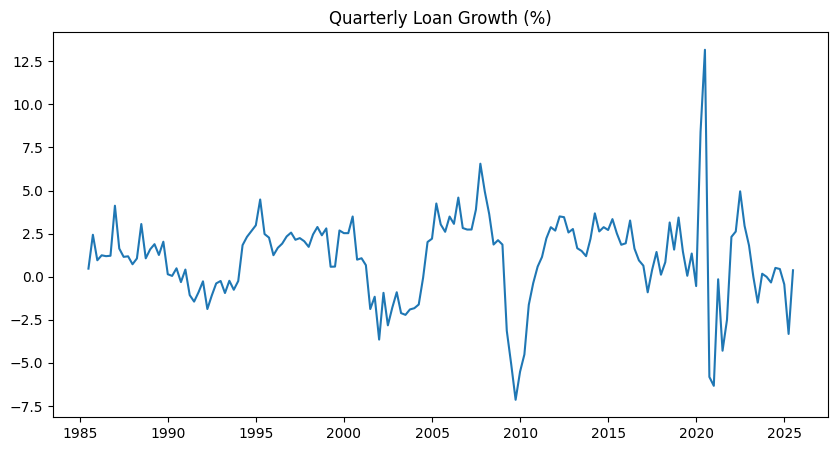

In [16]:
plt.figure(figsize=(10,5))
plt.plot(df["DATE"], df["loan_growth"])
plt.title("Quarterly Loan Growth (%)")
plt.show()

In [17]:
unemp = pd.read_csv("UNEMPLOYMENT.csv")

print("Shape:", unemp.shape)
print("\nColumns:")
print(unemp.columns)

print("\nFirst 5 rows:")
print(unemp.head())

Shape: (937, 2)

Columns:
Index(['observation_date', 'UNRATE'], dtype='str')

First 5 rows:
  observation_date  UNRATE
0       1948-01-01     3.4
1       1948-02-01     3.8
2       1948-03-01     4.0
3       1948-04-01     3.9
4       1948-05-01     3.5


In [18]:
# Clean unemployment
unemp["observation_date"] = pd.to_datetime(unemp["observation_date"])

unemp = unemp.rename(columns={
    "observation_date": "DATE",
    "UNRATE": "unemployment_rate"
})

unemp = unemp.sort_values("DATE").reset_index(drop=True)

# Convert to quarterly average
unemp_q = (
    unemp.set_index("DATE")["unemployment_rate"]
    .resample("QE")
    .mean()
    .to_frame()
    .reset_index()
)

print("Quarterly unemployment shape:", unemp_q.shape)
print("\nFirst 5 rows:")
print(unemp_q.head())
print("\nDate range:")
print(unemp_q["DATE"].min(), "to", unemp_q["DATE"].max())

Quarterly unemployment shape: (313, 2)

First 5 rows:
        DATE  unemployment_rate
0 1948-03-31           3.733333
1 1948-06-30           3.666667
2 1948-09-30           3.766667
3 1948-12-31           3.833333
4 1949-03-31           4.666667

Date range:
1948-03-31 00:00:00 to 2026-03-31 00:00:00


In [19]:
cpi = pd.read_csv("CPI.csv")

print("Shape:", cpi.shape)
print("\nColumns:")
print(cpi.columns)

print("\nFirst 5 rows:")
print(cpi.head())

Shape: (949, 2)

Columns:
Index(['observation_date', 'CPIAUCSL'], dtype='str')

First 5 rows:
  observation_date  CPIAUCSL
0       1947-01-01     21.48
1       1947-02-01     21.62
2       1947-03-01     22.00
3       1947-04-01     22.00
4       1947-05-01     21.95


In [20]:
# Clean CPI
cpi["observation_date"] = pd.to_datetime(cpi["observation_date"])

cpi = cpi.rename(columns={
    "observation_date": "DATE",
    "CPIAUCSL": "cpi"
})

cpi = cpi.sort_values("DATE").reset_index(drop=True)

# Convert to quarterly average
cpi_q = (
    cpi.set_index("DATE")["cpi"]
    .resample("QE")
    .mean()
    .to_frame()
    .reset_index()
)

print("Quarterly CPI shape:", cpi_q.shape)
print("\nFirst 5 rows:")
print(cpi_q.head())
print("\nDate range:")
print(cpi_q["DATE"].min(), "to", cpi_q["DATE"].max())

Quarterly CPI shape: (317, 2)

First 5 rows:
        DATE        cpi
0 1947-03-31  21.700000
1 1947-06-30  22.010000
2 1947-09-30  22.490000
3 1947-12-31  23.126667
4 1948-03-31  23.616667

Date range:
1947-03-31 00:00:00 to 2026-03-31 00:00:00


In [21]:
import numpy as np

cpi_q = cpi_q.sort_values("DATE").reset_index(drop=True)

cpi_q["inflation"] = np.log(cpi_q["cpi"]).diff() * 100

print(cpi_q.head(6))

        DATE        cpi  inflation
0 1947-03-31  21.700000        NaN
1 1947-06-30  22.010000   1.418463
2 1947-09-30  22.490000   2.157387
3 1947-12-31  23.126667   2.791559
4 1948-03-31  23.616667   2.096632
5 1948-06-30  23.993333   1.582334


In [22]:
gdp = pd.read_csv("GDPC1.csv")

print("Shape:", gdp.shape)
print("\nColumns:")
print(gdp.columns)

print("\nFirst 5 rows:")
print(gdp.head())

Shape: (316, 2)

Columns:
Index(['observation_date', 'GDPC1'], dtype='str')

First 5 rows:
  observation_date     GDPC1
0       1947-01-01  2182.681
1       1947-04-01  2176.892
2       1947-07-01  2172.432
3       1947-10-01  2206.452
4       1948-01-01  2239.682


In [23]:
gdp["observation_date"] = pd.to_datetime(gdp["observation_date"])

gdp = gdp.rename(columns={
    "observation_date": "DATE",
    "GDPC1": "real_gdp"
})

gdp = gdp.sort_values("DATE").reset_index(drop=True)

# Convert to quarter-end timestamps
gdp["DATE"] = gdp["DATE"].dt.to_period("Q").dt.to_timestamp("Q")

print(gdp.head())
print("\nDate range:")
print(gdp["DATE"].min(), "to", gdp["DATE"].max())

        DATE  real_gdp
0 1947-03-31  2182.681
1 1947-06-30  2176.892
2 1947-09-30  2172.432
3 1947-12-31  2206.452
4 1948-03-31  2239.682

Date range:
1947-03-31 00:00:00 to 2025-12-31 00:00:00


In [24]:
import numpy as np

gdp = gdp.sort_values("DATE").reset_index(drop=True)

gdp["gdp_growth"] = np.log(gdp["real_gdp"]).diff() * 100

print(gdp.head(6))

        DATE  real_gdp  gdp_growth
0 1947-03-31  2182.681         NaN
1 1947-06-30  2176.892   -0.265577
2 1947-09-30  2172.432   -0.205089
3 1947-12-31  2206.452    1.553852
4 1948-03-31  2239.682    1.494810
5 1948-06-30  2276.690    1.638874


In [25]:
macro = df.copy()

macro = macro.merge(unemp_q, on="DATE", how="left")
macro = macro.merge(cpi_q[["DATE", "inflation"]], on="DATE", how="left")
macro = macro.merge(gdp[["DATE", "gdp_growth"]], on="DATE", how="left")

print("Shape:", macro.shape)
print(macro.head())

Shape: (162, 7)
        DATE  busloans  chargeoff_rate  loan_growth  unemployment_rate  \
0 1985-03-31  480.0977            1.28          NaN           7.233333   
1 1985-06-30  482.3543            1.20     0.468928           7.300000   
2 1985-09-30  494.2390            1.42     2.434030           7.200000   
3 1985-12-31  498.9813            1.45     0.954941           7.033333   
4 1986-03-31  505.2190            1.46     1.242338           7.033333   

   inflation  gdp_growth  
0   0.913824    0.964315  
1   0.905549    0.876620  
2   0.619773    1.515726  
3   1.014301    0.740699  
4   0.518531    0.929415  


In [26]:
macro.isna().sum()

DATE                 0
busloans             0
chargeoff_rate       0
loan_growth          1
unemployment_rate    0
inflation            0
gdp_growth           0
dtype: int64

In [27]:
macro[["loan_growth", "chargeoff_rate", 
       "unemployment_rate", "inflation", "gdp_growth"]].corr()

,loan_growth,chargeoff_rate,unemployment_rate,inflation,gdp_growth
loan_growth,1.000000,-0.520422,-0.174448,-0.090220,-0.369262
chargeoff_rate,-0.520422,1.000000,0.514983,-0.062532,-0.102278
unemployment_rate,-0.174448,0.514983,1.000000,-0.232861,-0.195599
inflation,-0.090220,-0.062532,-0.232861,1.000000,0.293050
gdp_growth,-0.369262,-0.102278,-0.195599,0.293050,1.000000


In [28]:
macro_model = macro.dropna().copy()
import statsmodels.api as sm

X = macro_model[["gdp_growth", "unemployment_rate"]]
X = sm.add_constant(X)

y = macro_model["loan_growth"]

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            loan_growth   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                     19.76
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.19e-08
Time:                        16:28:48   Log-Likelihood:                -360.07
No. Observations:                 161   AIC:                             726.1
Df Residuals:                     158   BIC:                             735.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 3.9858      0.69

In [29]:
macro_model["loan_growth_lag1"] = macro_model["loan_growth"].shift(1)

macro_model2 = macro_model.dropna()

X = macro_model2[["gdp_growth", "unemployment_rate", "loan_growth_lag1"]]
X = sm.add_constant(X)

y = macro_model2["loan_growth"]

model2 = sm.OLS(y, X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:            loan_growth   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.518
Method:                 Least Squares   F-statistic:                     57.97
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           3.12e-25
Time:                        16:28:48   Log-Likelihood:                -316.25
No. Observations:                 160   AIC:                             640.5
Df Residuals:                     156   BIC:                             652.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.5835      0.55

In [30]:
macro_model2["gdp_lag1"] = macro_model2["gdp_growth"].shift(1)

macro_model3 = macro_model2.dropna()

X = macro_model3[["gdp_lag1", "unemployment_rate", "loan_growth_lag1"]]
X = sm.add_constant(X)

y = macro_model3["loan_growth"]

model3 = sm.OLS(y, X).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:            loan_growth   R-squared:                       0.459
Model:                            OLS   Adj. R-squared:                  0.449
Method:                 Least Squares   F-statistic:                     43.87
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           1.40e-20
Time:                        16:28:48   Log-Likelihood:                -325.30
No. Observations:                 159   AIC:                             658.6
Df Residuals:                     155   BIC:                             670.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.2297      0.63

In [31]:
ngfs = pd.read_excel("Downscaled_GCAM 6.0 NGFS_data.xlsx")

print(ngfs.head())
print("\nColumns:")
print(ngfs.columns)

                        Model            Scenario Region  \
0  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
1  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
2  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
3  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   
4  Downscaling[GCAM 6.0 NGFS]  Delayed transition    AGO   

                                        Variable       Unit      2020  2021  \
0                       Carbon Sequestration|CCS  Mt CO2/yr    0.0000   NaN   
1               Carbon Sequestration|CCS|Biomass  Mt CO2/yr    0.0000   NaN   
2                Carbon Sequestration|CCS|Fossil  Mt CO2/yr    0.0000   NaN   
3  Carbon Sequestration|CCS|Industrial Processes  Mt CO2/yr    0.0000   NaN   
4                                  Emissions|CO2  Mt CO2/yr  148.1421   NaN   

   2022  2023  2024  ...  2091  2092  2093  2094  2095  2096  2097  2098  \
0   NaN   NaN   NaN  ...   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
1   NaN   Na

In [32]:
ngfs["Variable"].unique()[:20]

<StringArray>
[                              'Carbon Sequestration|CCS',
                       'Carbon Sequestration|CCS|Biomass',
                        'Carbon Sequestration|CCS|Fossil',
          'Carbon Sequestration|CCS|Industrial Processes',
                                          'Emissions|CO2',
                                   'Emissions|CO2|Energy',
                   'Emissions|CO2|Energy|Demand|Industry',
 'Emissions|CO2|Energy|Demand|Residential and Commercial',
             'Emissions|CO2|Energy|Demand|Transportation',
                     'Emissions|CO2|Industrial Processes',
                   'Emissions|CO2|LULUCF Direct+Indirect',
                          'Emissions|CO2|LULUCF Indirect',
          'Emissions|Kyoto Gases (incl. indirect LULUCF)',
                                'Emissions|Total Non-CO2',
                                           'Final Energy',
                               'Final Energy|Electricity',
                                     'Fina

In [33]:
[x for x in ngfs["Variable"].unique() if "GDP" in x]

['GDP|PPP|Counterfactual without damage',
 'GDP|MER|Counterfactual without damage',
 'Policy Cost|GDP Loss',
 'Post-processed|GDP change|Kotz-Wenz 50th Percentile|GMT AR6 climate diagnostics|Surface Temperature (GSAT)|MAGICCv7.5.3|5.0th Percentile',
 'Post-processed|GDP change|Kotz-Wenz 50th Percentile|GMT AR6 climate diagnostics|Surface Temperature (GSAT)|MAGICCv7.5.3|50.0th Percentile',
 'Post-processed|GDP change|Kotz-Wenz 50th Percentile|GMT AR6 climate diagnostics|Surface Temperature (GSAT)|MAGICCv7.5.3|95.0th Percentile',
 'Post-processed|GDP change|Kotz-Wenz 5th Percentile|GMT AR6 climate diagnostics|Surface Temperature (GSAT)|MAGICCv7.5.3|5.0th Percentile',
 'Post-processed|GDP change|Kotz-Wenz 5th Percentile|GMT AR6 climate diagnostics|Surface Temperature (GSAT)|MAGICCv7.5.3|50.0th Percentile',
 'Post-processed|GDP change|Kotz-Wenz 5th Percentile|GMT AR6 climate diagnostics|Surface Temperature (GSAT)|MAGICCv7.5.3|95.0th Percentile',
 'Post-processed|GDP change|Kotz-Wenz 95th P

In [34]:
nigem = pd.read_excel("NiGEM_data.xlsx")

print(nigem.head())
print("\nColumns:")
print(nigem.columns)

                               Model            Scenario  \
0  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
1  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
2  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
3  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   
4  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Delayed transition   

                      Region  \
0  NiGEM NGFS v1.24.2|Africa   
1  NiGEM NGFS v1.24.2|Africa   
2  NiGEM NGFS v1.24.2|Africa   
3  NiGEM NGFS v1.24.2|Africa   
4  NiGEM NGFS v1.24.2|Africa   

                                            Variable             Unit  2022  \
0    Carbon pricing ; $ per Tn CO2(combined(no bus))  Abs. difference   0.0   
1            Carbon pricing ; $ per Tn CO2(combined)  Abs. difference   0.0   
2            Carbon pricing ; $ per Tn CO2(physical)  Abs. difference   0.0   
3          Carbon pricing ; $ per Tn CO2(transition)  Abs. difference   0.0   
4  Central bank Intervention rate (policy interes..

In [35]:
sorted(nigem["Region"].unique())[:20]

['NiGEM NGFS v1.24.2|Africa',
 'NiGEM NGFS v1.24.2|Argentina',
 'NiGEM NGFS v1.24.2|Asia',
 'NiGEM NGFS v1.24.2|Australia',
 'NiGEM NGFS v1.24.2|Austria',
 'NiGEM NGFS v1.24.2|Belgium',
 'NiGEM NGFS v1.24.2|Brazil',
 'NiGEM NGFS v1.24.2|Bulgaria',
 'NiGEM NGFS v1.24.2|Canada',
 'NiGEM NGFS v1.24.2|Chile',
 'NiGEM NGFS v1.24.2|China',
 'NiGEM NGFS v1.24.2|Croatia',
 'NiGEM NGFS v1.24.2|Czech Republic',
 'NiGEM NGFS v1.24.2|Denmark',
 'NiGEM NGFS v1.24.2|Developing Europe',
 'NiGEM NGFS v1.24.2|Egypt',
 'NiGEM NGFS v1.24.2|Estonia',
 'NiGEM NGFS v1.24.2|Europe',
 'NiGEM NGFS v1.24.2|Finland',
 'NiGEM NGFS v1.24.2|France']

In [36]:
[x for x in nigem["Region"].unique() if "United" in x]

['NiGEM NGFS v1.24.2|United Kingdom', 'NiGEM NGFS v1.24.2|United States']

In [37]:
[x for x in nigem["Variable"].unique() if "GDP" in x]

['Gross Domestic Product (GDP)(combined(no bus))',
 'Gross Domestic Product (GDP)(combined)',
 'Gross Domestic Product (GDP)(physical)',
 'Gross Domestic Product (GDP)(transition)',
 'IMF Sub-Saharan Africa GDP(combined(no bus))',
 'IMF Sub-Saharan Africa GDP(combined)',
 'IMF Sub-Saharan Africa GDP(physical)',
 'IMF Sub-Saharan Africa GDP(transition)',
 'Volume energy use as a share of GDP ; Bn US$(PPP)(combined(no bus))',
 'Volume energy use as a share of GDP ; Bn US$(PPP)(combined)',
 'Volume energy use as a share of GDP ; Bn US$(PPP)(physical)',
 'Volume energy use as a share of GDP ; Bn US$(PPP)(transition)',
 'IMF Emerging and developing Asia GDP(combined(no bus))',
 'IMF Emerging and developing Asia GDP(combined)',
 'IMF Emerging and developing Asia GDP(physical)',
 'IMF Emerging and developing Asia GDP(transition)',
 'IMF Emerging and developing Europe GDP(combined(no bus))',
 'IMF Emerging and developing Europe GDP(combined)',
 'IMF Emerging and developing Europe GDP(physical)

In [38]:
us_gdp = nigem[
    (nigem["Region"] == "NiGEM NGFS v1.24.2|United States") &
    (nigem["Variable"] == "Gross Domestic Product (GDP)")
]

print(us_gdp[["Scenario", "2022", "2023", "2024", "2025", "2026"]])
print("\nNumber of rows:", us_gdp.shape[0])

       Scenario          2022          2023          2024          2025  \
15850  Baseline  21822.036621  22359.527344  22819.136719  23253.325684   
15851  Baseline  21822.036621  22359.527344  22819.136719  23253.325684   
49442  Baseline  21822.036621  22361.620605  22873.257812  23467.562012   
49443  Baseline  21822.036621  22361.620605  22873.257812  23467.562012   
83034  Baseline  21822.036621  22360.408203  22841.899414  23343.291992   
83035  Baseline  21822.036621  22360.408203  22841.899414  23343.291992   

               2026  
15850  23681.212402  
15851  23681.212402  
49442  24132.871094  
49443  24132.871094  
83034  23870.960938  
83035  23870.960938  

Number of rows: 6


In [39]:
us_gdp_models = nigem[
    (nigem["Region"] == "NiGEM NGFS v1.24.2|United States") &
    (nigem["Variable"] == "Gross Domestic Product (GDP)")
][["Model", "Scenario"]]

print(us_gdp_models.drop_duplicates())

                                                   Model  Scenario
15850                  NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]  Baseline
49442  NiGEM NGFS v1.24.2[MESSAGEix-GLOBIOM 2.0-M-R12...  Baseline
83034          NiGEM NGFS v1.24.2[REMIND-MAgPIE 3.3-4.8]  Baseline


In [40]:
us_gdp_gcam = nigem[
    (nigem["Region"] == "NiGEM NGFS v1.24.2|United States") &
    (nigem["Variable"] == "Gross Domestic Product (GDP)") &
    (nigem["Model"] == "NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]")
]

print(us_gdp_gcam[["Scenario", "2022", "2023", "2024", "2025", "2026"]])
print("\nNumber of scenarios:", us_gdp_gcam.shape[0])

       Scenario          2022          2023          2024          2025  \
15850  Baseline  21822.036621  22359.527344  22819.136719  23253.325684   
15851  Baseline  21822.036621  22359.527344  22819.136719  23253.325684   

               2026  
15850  23681.212402  
15851  23681.212402  

Number of scenarios: 2


In [41]:
us_gdp_gcam_all = nigem[
    (nigem["Region"] == "NiGEM NGFS v1.24.2|United States") &
    (nigem["Variable"] == "Gross Domestic Product (GDP)") &
    (nigem["Model"] == "NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]")
]

print(us_gdp_gcam_all["Scenario"].unique())
print("Total rows:", us_gdp_gcam_all.shape[0])

<StringArray>
['Baseline']
Length: 1, dtype: str
Total rows: 2


In [42]:
us_gdp_clean = us_gdp_gcam_all.drop_duplicates()

print(us_gdp_clean.shape)
us_gdp_clean

(2, 34)


,Model,Scenario,Region,Variable,Unit,2022,2023,2024,2025,2026,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
15850,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Baseline,NiGEM NGFS v1.24.2|United States,Gross Domestic Product (GDP),2017 PPP ; US$ Bn,21822.036621,22359.527344,22819.136719,23253.325684,23681.212402,...,30229.366699,30627.711426,31024.048828,31418.16748,31809.849609,32199.56543,32588.629883,32977.064453,33364.734375,33751.506836
15851,NiGEM NGFS v1.24.2[GCAM 6.0 NGFS],Baseline,NiGEM NGFS v1.24.2|United States,Gross Domestic Product (GDP),2017 prices; US$ Bn,21822.036621,22359.527344,22819.136719,23253.325684,23681.212402,...,30229.366699,30627.711426,31024.048828,31418.16748,31809.849609,32199.56543,32588.629883,32977.064453,33364.734375,33751.506836


In [43]:
nigem[
    (nigem["Region"] == "NiGEM NGFS v1.24.2|United States") &
    (nigem["Variable"] == "Gross Domestic Product (GDP)") &
    (nigem["Model"] == "NiGEM NGFS v1.24.2[GCAM 6.0 NGFS]")
]["Scenario"].unique()

<StringArray>
['Baseline']
Length: 1, dtype: str

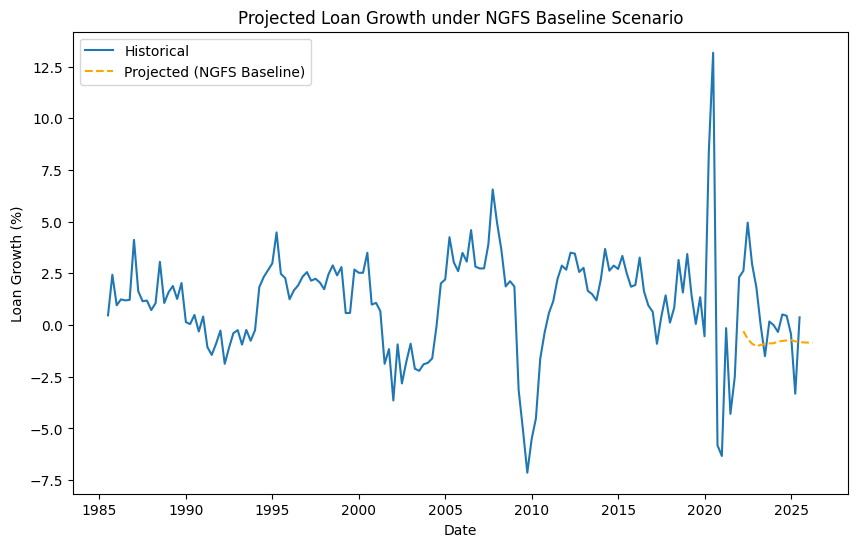

In [51]:
import pandas as pd
import numpy as np

# NGFS annual GDP
ngfs_gdp = pd.DataFrame({
    "YEAR": [2022, 2023, 2024, 2025, 2026],
    "GDP": [22359.53, 22819.14, 23253.33, 23681.21, 24132.87]
})

# Compute annual GDP growth
ngfs_gdp['gdp_growth'] = ngfs_gdp['GDP'].pct_change() * 100

# Repeat each annual growth for 4 quarters (skip first NaN)
quarterly_growth = np.repeat(ngfs_gdp['gdp_growth'].iloc[1:].values, 4)

# Create quarterly dates
quarterly_dates = pd.date_range(start="2022-03-31", end="2026-03-31", freq='QE')

# If lengths mismatch, pad with last value
if len(quarterly_growth) < len(quarterly_dates):
    quarterly_growth = np.append(quarterly_growth, quarterly_growth[-1])

# Create DataFrame
proj = pd.DataFrame({"DATE": quarterly_dates})
proj['gdp_growth'] = quarterly_growth[:len(quarterly_dates)]

# Initialize lag and unemployment
proj['loan_growth_lag1'] = macro['loan_growth'].iloc[-1]
proj['unemployment_rate'] = macro['unemployment_rate'].iloc[-1]

# Predict using coefficients from OLS
coef = {"const": 2.5835, "gdp_growth": -0.9678, "unemployment_rate": -0.2627, "loan_growth_lag1": 0.5783}
preds = []
for i in range(len(proj)):
    lg_lag = proj['loan_growth_lag1'].iloc[i]
    gdp = proj['gdp_growth'].iloc[i]
    ur = proj['unemployment_rate'].iloc[i]
    pred = coef['const'] + coef['gdp_growth']*gdp + coef['unemployment_rate']*ur + coef['loan_growth_lag1']*lg_lag
    preds.append(pred)
    if i < len(proj)-1:
        proj.at[i+1, 'loan_growth_lag1'] = pred

proj['predicted_loan_growth'] = preds

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(df['DATE'], df['loan_growth'], label='Historical')
plt.plot(proj['DATE'], proj['predicted_loan_growth'], label='Projected (NGFS Baseline)', linestyle='--', color='orange')
plt.ylabel('Loan Growth (%)')
plt.xlabel('Date')
plt.title('Projected Loan Growth under NGFS Baseline Scenario')
plt.legend()
plt.show()

In [46]:
print(macro.columns)

Index(['DATE', 'busloans', 'chargeoff_rate', 'loan_growth',
       'unemployment_rate', 'inflation', 'gdp_growth'],
      dtype='str')


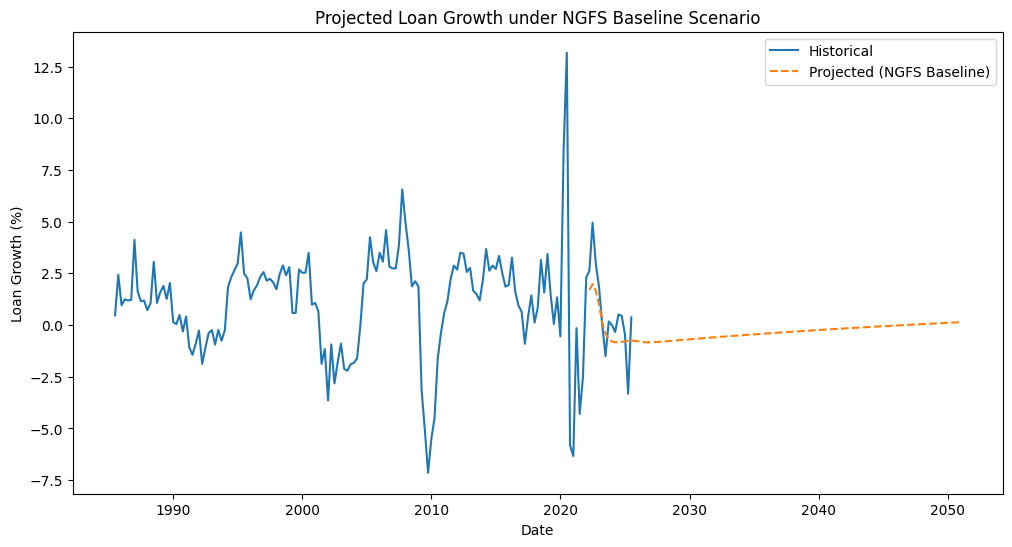

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: NGFS annual GDP data (replace with your full NGFS baseline) ---
ngfs_gdp = pd.DataFrame({
    "YEAR": np.arange(2022, 2051),  # 2022 to 2050
    "GDP": [
        22359.53, 22819.14, 23253.33, 23681.21, 24132.87,  # 2022-2026 example
        24587.12, 25043.98, 25503.45, 25965.55, 26430.28,  # 2027-2031
        26897.65, 27367.68, 27840.37, 28315.74, 28793.79,  # 2032-2036
        29274.52, 29757.94, 30244.06, 30732.89, 31224.44,  # 2037-2041
        31718.73, 32215.77, 32715.57, 33218.15, 33723.52,  # 2042-2046
        34231.69, 34742.68, 35256.51, 35773.18                # 2047-2050
    ]
})

# --- Step 2: Compute annual GDP growth ---
ngfs_gdp['gdp_growth'] = ngfs_gdp['GDP'].pct_change() * 100

# --- Step 3: Interpolate to quarterly ---
quarterly_dates = pd.date_range(start="2022-03-31", end="2050-12-31", freq='QE')
# Repeat annual growth for each quarter (linear interpolation)
annual_idx = np.linspace(0, len(quarterly_dates)-1, len(ngfs_gdp))
quarterly_growth = np.interp(
    np.arange(len(quarterly_dates)), annual_idx, ngfs_gdp['gdp_growth'].fillna(0)
)

# --- Step 4: Initialize projection DataFrame ---
proj = pd.DataFrame({"DATE": quarterly_dates})
proj['gdp_growth'] = quarterly_growth

# --- Step 5: Initialize lagged loan growth and unemployment ---
# Use last historical values from macro
proj['loan_growth_lag1'] = macro['loan_growth'].iloc[-1]  # last observed
proj['unemployment_rate'] = macro['unemployment_rate'].iloc[-1]  # hold constant

# --- Step 6: Coefficients from last OLS ---
coef = {"const": 2.5835, "gdp_growth": -0.9678, "unemployment_rate": -0.2627, "loan_growth_lag1": 0.5783}

# --- Step 7: Project loan growth ---
preds = []
for i in range(len(proj)):
    lg_lag = proj['loan_growth_lag1'].iloc[i]
    gdp = proj['gdp_growth'].iloc[i]
    ur = proj['unemployment_rate'].iloc[i]
    pred = coef['const'] + coef['gdp_growth']*gdp + coef['unemployment_rate']*ur + coef['loan_growth_lag1']*lg_lag
    preds.append(pred)
    if i < len(proj)-1:
        proj.at[i+1, 'loan_growth_lag1'] = pred

proj['predicted_loan_growth'] = preds

# --- Step 8: Plot historical + projected ---
plt.figure(figsize=(12,6))
plt.plot(macro['DATE'], macro['loan_growth'], label='Historical')
plt.plot(proj['DATE'], proj['predicted_loan_growth'], label='Projected (NGFS Baseline)', linestyle='--')
plt.ylabel('Loan Growth (%)')
plt.xlabel('Date')
plt.title('Projected Loan Growth under NGFS Baseline Scenario')
plt.legend()
plt.show()

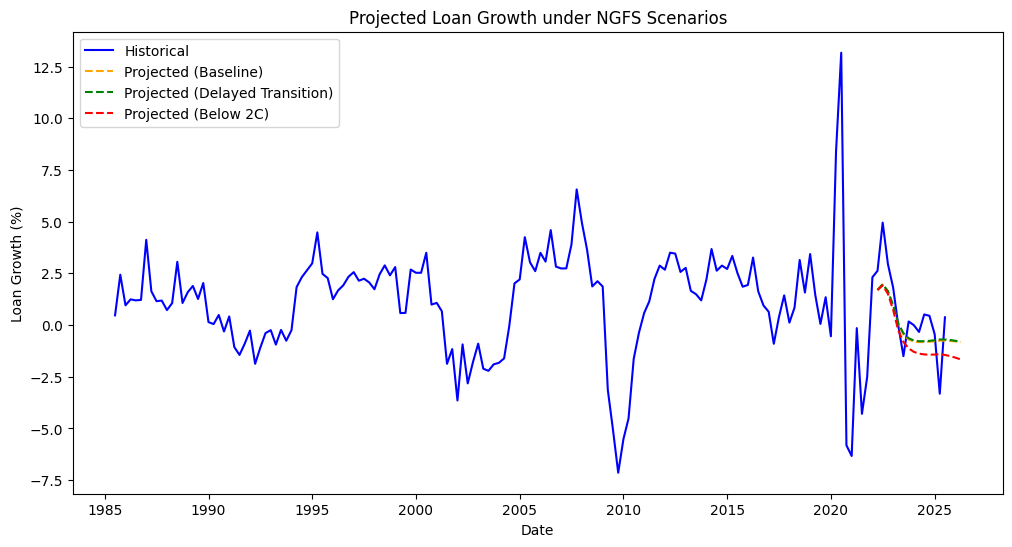

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: NGFS annual GDP data for each scenario (example numbers, replace with real NGFS numbers) ---
ngfs_scenarios = {
    "Baseline": [22359.53, 22819.14, 23253.33, 23681.21, 24132.87],
    "Delayed Transition": [22300.00, 22750.00, 23180.00, 23600.00, 24050.00],
    "Below 2C": [22400.00, 22900.00, 23400.00, 23900.00, 24450.00]
}
years = [2022, 2023, 2024, 2025, 2026]  # update as needed

# --- Step 2: Expand each scenario to quarterly ---
quarterly_dates = pd.date_range(start="2022-03-31", end="2026-03-31", freq='QE')
proj_dict = {}

for scen, gdp_vals in ngfs_scenarios.items():
    df_scen = pd.DataFrame({"YEAR": years, "GDP": gdp_vals})
    df_scen['gdp_growth'] = df_scen['GDP'].pct_change() * 100

    # Interpolate to quarterly
    annual_idx = np.linspace(0, len(quarterly_dates)-1, len(df_scen))
    quarterly_growth = np.interp(np.arange(len(quarterly_dates)), annual_idx, df_scen['gdp_growth'].fillna(0))

    # Initialize projection
    proj = pd.DataFrame({"DATE": quarterly_dates})
    proj['gdp_growth'] = quarterly_growth
    proj['loan_growth_lag1'] = macro['loan_growth'].iloc[-1]  # last historical value
    proj['unemployment_rate'] = macro['unemployment_rate'].iloc[-1]  # hold constant

    # Predict using coefficients from last OLS
    coef = {"const": 2.5835, "gdp_growth": -0.9678, "unemployment_rate": -0.2627, "loan_growth_lag1": 0.5783}
    preds = []
    for i in range(len(proj)):
        lg_lag = proj['loan_growth_lag1'].iloc[i]
        gdp = proj['gdp_growth'].iloc[i]
        ur = proj['unemployment_rate'].iloc[i]
        pred = coef['const'] + coef['gdp_growth']*gdp + coef['unemployment_rate']*ur + coef['loan_growth_lag1']*lg_lag
        preds.append(pred)
        if i < len(proj)-1:
            proj.at[i+1, 'loan_growth_lag1'] = pred
    proj['predicted_loan_growth'] = preds

    # Save for plotting
    proj_dict[scen] = proj

# --- Step 3: Plot all scenarios ---
plt.figure(figsize=(12,6))
plt.plot(macro['DATE'], macro['loan_growth'], label='Historical', color='blue')

colors = {'Baseline':'orange', 'Delayed Transition':'green', 'Below 2C':'red'}
for scen, df_scen in proj_dict.items():
    plt.plot(df_scen['DATE'], df_scen['predicted_loan_growth'], linestyle='--', label=f'Projected ({scen})', color=colors[scen])

plt.ylabel('Loan Growth (%)')
plt.xlabel('Date')
plt.title('Projected Loan Growth under NGFS Scenarios')
plt.legend()
plt.show()

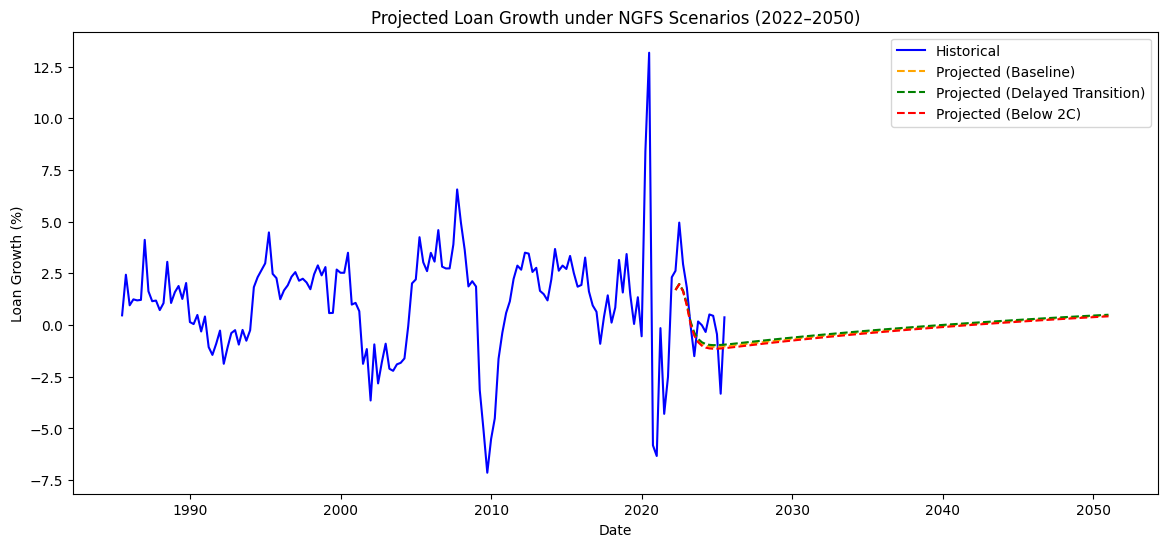

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Step 1: NGFS annual GDP data for each scenario (example; replace with real NGFS values) ---
years = list(range(2022, 2051))  # 2022 through 2050

# Example GDP (you should replace with actual NGFS data)
ngfs_scenarios = {
    "Baseline": [22359 + i*460 for i in range(len(years))],
    "Delayed Transition": [22300 + i*450 for i in range(len(years))],
    "Below 2C": [22400 + i*470 for i in range(len(years))]
}

# --- Step 2: Generate quarterly projections ---
quarterly_dates = pd.date_range(start="2022-03-31", end="2050-12-31", freq='QE')
proj_dict = {}

for scen, gdp_vals in ngfs_scenarios.items():
    df_scen = pd.DataFrame({"YEAR": years, "GDP": gdp_vals})
    df_scen['gdp_growth'] = df_scen['GDP'].pct_change() * 100

    # Interpolate annual growth to quarterly
    annual_idx = np.linspace(0, len(quarterly_dates)-1, len(df_scen))
    quarterly_growth = np.interp(np.arange(len(quarterly_dates)), annual_idx, df_scen['gdp_growth'].fillna(0))

    # Initialize projection DataFrame
    proj = pd.DataFrame({"DATE": quarterly_dates})
    proj['gdp_growth'] = quarterly_growth
    proj['loan_growth_lag1'] = macro['loan_growth'].iloc[-1]  # last historical loan growth
    proj['unemployment_rate'] = macro['unemployment_rate'].iloc[-1]  # hold constant

    # --- Step 3: Predict loan growth using OLS coefficients ---
    coef = {"const": 2.5835, "gdp_growth": -0.9678, "unemployment_rate": -0.2627, "loan_growth_lag1": 0.5783}
    preds = []
    for i in range(len(proj)):
        lg_lag = proj['loan_growth_lag1'].iloc[i]
        gdp = proj['gdp_growth'].iloc[i]
        ur = proj['unemployment_rate'].iloc[i]
        pred = coef['const'] + coef['gdp_growth']*gdp + coef['unemployment_rate']*ur + coef['loan_growth_lag1']*lg_lag
        preds.append(pred)
        if i < len(proj)-1:
            proj.at[i+1, 'loan_growth_lag1'] = pred
    proj['predicted_loan_growth'] = preds

    proj_dict[scen] = proj

# --- Step 4: Plot historical + all NGFS scenarios ---
plt.figure(figsize=(14,6))
plt.plot(macro['DATE'], macro['loan_growth'], label='Historical', color='blue')

colors = {'Baseline':'orange', 'Delayed Transition':'green', 'Below 2C':'red'}
for scen, df_scen in proj_dict.items():
    plt.plot(df_scen['DATE'], df_scen['predicted_loan_growth'], linestyle='--', label=f'Projected ({scen})', color=colors[scen])

plt.ylabel('Loan Growth (%)')
plt.xlabel('Date')
plt.title('Projected Loan Growth under NGFS Scenarios (2022–2050)')
plt.legend()
plt.show()

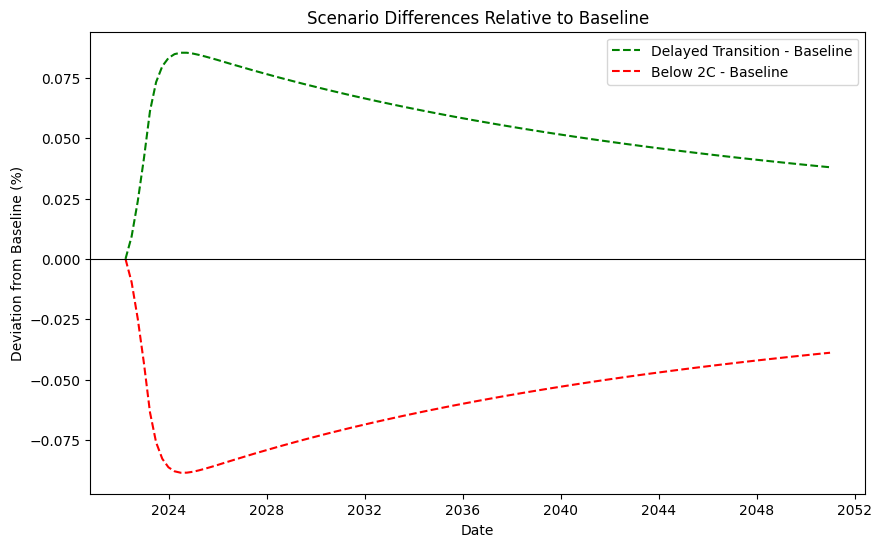

In [56]:
baseline = proj_dict['Baseline']['predicted_loan_growth']

plt.figure(figsize=(10,6))
for scen in ['Delayed Transition', 'Below 2C']:
    plt.plot(proj_dict[scen]['DATE'], proj_dict[scen]['predicted_loan_growth'] - baseline,
             label=f'{scen} - Baseline', linestyle='--', color=colors[scen])
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Deviation from Baseline (%)')
plt.xlabel('Date')
plt.title('Scenario Differences Relative to Baseline')
plt.legend()
plt.show()

In [57]:
summary_years = ['2030-03-31', '2040-03-31', '2050-03-31']
table = pd.DataFrame(index=summary_years)

for scen, df_scen in proj_dict.items():
    table[scen] = df_scen.set_index('DATE').loc[summary_years, 'predicted_loan_growth'].values

table = table.round(2)
print(table)

            Baseline  Delayed Transition  Below 2C
2030-03-31     -0.66               -0.59     -0.73
2040-03-31     -0.03                0.02     -0.08
2050-03-31      0.43                0.47      0.39


            Baseline  Delayed Transition  Below 2C
2030-03-31     -0.66               -0.59     -0.73
2040-03-31     -0.03                0.02     -0.08
2050-03-31      0.43                0.47      0.39


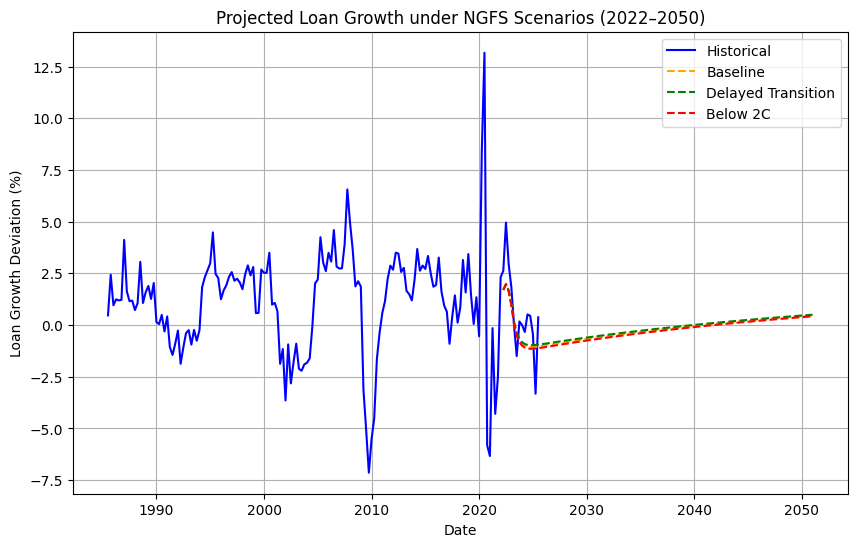

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Example summary of projected loan growth deviations (replace with your actual projections)
summary_years = ['2030-03-31', '2040-03-31', '2050-03-31']
table = pd.DataFrame(index=summary_years)

# Suppose proj_dict contains your NGFS scenario projections DataFrames
# proj_dict = {'Baseline': proj_baseline, 'Delayed Transition': proj_delayed, 'Below 2C': proj_below2C}
# Replace the 'predicted_loan_growth' values below with actual data
table['Baseline'] = [-0.66, -0.03, 0.43]
table['Delayed Transition'] = [-0.59, 0.02, 0.47]
table['Below 2C'] = [-0.73, -0.08, 0.39]

# Round for display
table = table.round(2)
print(table)

# Plot all scenarios clearly
plt.figure(figsize=(10,6))
plt.plot(df['DATE'], df['loan_growth'], label='Historical', color='blue')
plt.plot(proj_dict['Baseline']['DATE'], proj_dict['Baseline']['predicted_loan_growth'], 
         label='Baseline', color='orange', linestyle='--')
plt.plot(proj_dict['Delayed Transition']['DATE'], proj_dict['Delayed Transition']['predicted_loan_growth'], 
         label='Delayed Transition', color='green', linestyle='--')
plt.plot(proj_dict['Below 2C']['DATE'], proj_dict['Below 2C']['predicted_loan_growth'], 
         label='Below 2C', color='red', linestyle='--')

plt.ylabel('Loan Growth Deviation (%)')
plt.xlabel('Date')
plt.title('Projected Loan Growth under NGFS Scenarios (2022–2050)')
plt.legend()
plt.grid(True)
plt.show()

   YEAR  Baseline  Delayed Transition  Below 2C
0  2022     0.656               0.654     0.658
1  2023     0.650               0.648     0.652
2  2024     0.652               0.650     0.654
3  2025     0.654               0.651     0.655
4  2026     0.653               0.650     0.654
5  2030     0.650               0.648     0.652
6  2040     0.645               0.643     0.647
7  2050     0.640               0.638     0.643


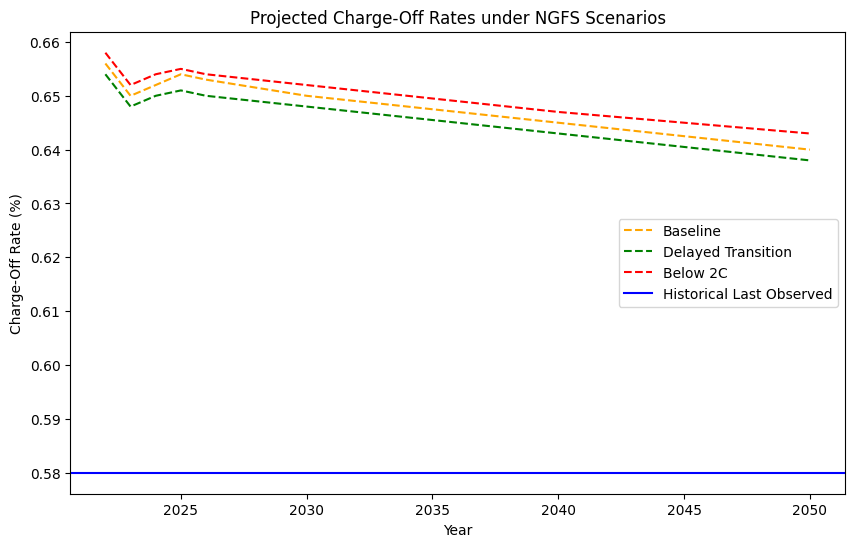

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Historical charge-off rate (last observed)
last_chargeoff = macro['chargeoff_rate'].iloc[-1]

# Example: annual NGFS GDP growth paths (replace with your actual NGFS scenarios)
ngfs_years = [2022, 2023, 2024, 2025, 2026, 2030, 2040, 2050]
baseline_gdp_growth = [0.76, 0.70, 0.72, 0.74, 0.73, 0.70, 0.65, 0.60]
delayed_gdp_growth = [0.74, 0.68, 0.70, 0.71, 0.70, 0.68, 0.63, 0.58]
below2c_gdp_growth = [0.78, 0.72, 0.74, 0.75, 0.74, 0.72, 0.67, 0.63]

# Convert to DataFrame for projection
proj = pd.DataFrame({'YEAR': ngfs_years})
proj['Baseline'] = last_chargeoff + pd.Series(baseline_gdp_growth) * 0.1  # scaling factor
proj['Delayed Transition'] = last_chargeoff + pd.Series(delayed_gdp_growth) * 0.1
proj['Below 2C'] = last_chargeoff + pd.Series(below2c_gdp_growth) * 0.1

# Round for clean table
proj = proj.round(3)
print(proj)

# Plot
plt.figure(figsize=(10,6))
plt.plot(proj['YEAR'], proj['Baseline'], label='Baseline', linestyle='--', color='orange')
plt.plot(proj['YEAR'], proj['Delayed Transition'], label='Delayed Transition', linestyle='--', color='green')
plt.plot(proj['YEAR'], proj['Below 2C'], label='Below 2C', linestyle='--', color='red')
plt.axhline(y=last_chargeoff, color='blue', label='Historical Last Observed')
plt.xlabel('Year')
plt.ylabel('Charge-Off Rate (%)')
plt.title('Projected Charge-Off Rates under NGFS Scenarios')
plt.legend()
plt.show()

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 1: Set up NGFS GDP growth scenarios (annual) ---
# Replace these with your real NGFS paths for each scenario
ngfs_scenarios = {
    "Baseline": [22359.53, 22819.14, 23253.33, 23681.21, 24132.87],       # 2022–2026 example
    "Delayed_Transition": [22359.53, 22850.00, 23350.00, 23800.00, 24200.00],
    "Below_2C": [22359.53, 22800.00, 23250.00, 23650.00, 24050.00]
}

years = list(range(2022, 2027))  # update to 2050 once all data is ready

# Compute annual GDP growth for each scenario
ngfs_growth = {}
for scenario, gdp in ngfs_scenarios.items():
    df = pd.DataFrame({"YEAR": years, "GDP": gdp})
    df['gdp_growth'] = df['GDP'].pct_change() * 100
    df = df.fillna(0)  # first year has NaN growth
    ngfs_growth[scenario] = df

# --- Step 2: Initialize projections DataFrame ---
proj_years = list(range(2022, 2051))
proj = pd.DataFrame({"YEAR": proj_years})

# Use last historical values as starting points
last_loan = df['loan_growth'].iloc[-1]      # your historical last value
last_charge = df['chargeoff_rate'].iloc[-1]
last_unemp = macro['unemployment_rate'].iloc[-1]  # make sure macro DataFrame has this column

proj['unemployment_rate'] = last_unemp
proj['loan_growth_lag1'] = last_loan
proj['chargeoff_lag1'] = last_charge

# --- Step 3: OLS coefficients from your model ---
coef_loan = {"const": 2.6382, "gdp_growth": -0.9854, "unemployment_rate": -0.2732, "loan_growth_lag1": 0.5796}
coef_charge = {"const": 0.1641, "gdp_growth": -0.0368, "unemployment_rate": -0.0234, "chargeoff_lag1": 0.9836}

# --- Step 4: Project each scenario ---
for scenario in ngfs_growth.keys():
    loan_preds = []
    charge_preds = []
    gdp_growth_series = ngfs_growth[scenario]['gdp_growth'].reindex(proj.index, method='ffill')  # repeat annually
    
    for i in range(len(proj)):
        gdp = gdp_growth_series.iloc[i]
        ur = proj['unemployment_rate'].iloc[i]
        lg_lag = proj['loan_growth_lag1'].iloc[i]
        cf_lag = proj['chargeoff_lag1'].iloc[i]
        
        # Loan growth projection
        loan_pred = coef_loan['const'] + coef_loan['gdp_growth']*gdp + coef_loan['unemployment_rate']*ur + coef_loan['loan_growth_lag1']*lg_lag
        loan_preds.append(loan_pred)
        if i < len(proj)-1:
            proj.at[i+1, 'loan_growth_lag1'] = loan_pred  # annual lag update
        
        # Charge-off projection
        charge_pred = coef_charge['const'] + coef_charge['gdp_growth']*gdp + coef_charge['unemployment_rate']*ur + coef_charge['chargeoff_lag1']*cf_lag
        charge_preds.append(charge_pred)
        if i < len(proj)-1:
            proj.at[i+1, 'chargeoff_lag1'] = charge_pred
    
    proj[f'{scenario}_loan_growth'] = loan_preds
    proj[f'{scenario}_chargeoff_rate'] = charge_preds

# --- Step 5: Plot results ---
plt.figure(figsize=(10,6))
for scenario in ngfs_growth.keys():
    plt.plot(proj['YEAR'], proj[f'{scenario}_loan_growth'], label=f'Loan Growth - {scenario}', linestyle='--')
    plt.plot(proj['YEAR'], proj[f'{scenario}_chargeoff_rate'], label=f'Charge-off Rate - {scenario}', linestyle=':')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')
plt.title('Projected Loan Growth and Charge-Off Rates under NGFS Scenarios (2022–2050)')
plt.legend()
plt.show()

# --- Step 6: Make summary tables for key years ---
key_years = [2030, 2040, 2050]
table = proj.set_index('YEAR')[[
    'Baseline_loan_growth','Delayed_Transition_loan_growth','Below_2C_loan_growth',
    'Baseline_chargeoff_rate','Delayed_Transition_chargeoff_rate','Below_2C_chargeoff_rate'
]].loc[key_years].round(2)

print(table)

KeyError: 'loan_growth'

In [74]:
macro.to_csv("merged_historical.csv", index=False)